### Reload state

In [2]:
import pandas as pd
import numpy as np
import joblib
import os
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap

warnings.filterwarnings("ignore")

In [3]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

BASE_DIR   = r"C:\Users\RAJA\Desktop\DA\Projects\FailSafe\backend\ml"
MODELS_DIR = os.path.join(BASE_DIR, "models")
DATA_DIR   = os.path.join(BASE_DIR, "data")

In [4]:
# Load artifacts
xgb_model    = joblib.load(os.path.join(MODELS_DIR, "xgb_model.pkl"))
rf_model     = joblib.load(os.path.join(MODELS_DIR, "rf_model.pkl"))
scaler       = joblib.load(os.path.join(MODELS_DIR, "scaler.pkl"))
encoders     = joblib.load(os.path.join(MODELS_DIR, "encoders.pkl"))
metadata     = joblib.load(os.path.join(MODELS_DIR, "metadata.pkl"))

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [6]:
# Rebuild X_test
df = pd.read_csv(os.path.join(DATA_DIR, "student-por.csv"), sep=";")
df["risk_binary"] = (df["G3"] < 10).astype(int)
df["risk_level"]  = pd.cut(df["G3"], bins=[-1, 9, 14, 20],
                            labels=[0, 1, 2]).astype(int)
df["absences"]    = df["absences"].clip(upper=df["absences"].quantile(0.95))

df_model = df.copy()
for col, le in encoders.items():
    if col in df_model.columns:
        df_model[col] = le.transform(df_model[col].astype(str))

DROP_COLS  = metadata["drop_cols"]
SCALE_COLS = metadata["scale_cols"]

X        = df_model.drop(columns=DROP_COLS, errors="ignore")
y        = df["risk_binary"]
X_scaled = X.copy()
X_scaled[SCALE_COLS] = scaler.transform(X[SCALE_COLS])

_, X_test, _, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("State reloaded ✓")
print(f"X_test : {X_test.shape}")
print(f"At-risk in test: {y_test.sum()} students")

State reloaded ✓
X_test : (130, 28)
At-risk in test: 20 students


#### SHAP explainer + values

In [7]:
# TreeExplainer is optimized for tree-based models
# shap_values shape will be (130, 28) — one row per test student
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"Explainer ready ✓")
print(f"SHAP values shape  : {shap_values.shape}")
print(f"Baseline (expected): {explainer.expected_value:.4f}")

# Global importance — mean absolute SHAP per feature
shap_importance = pd.DataFrame({
    "feature"   : X_test.columns,
    "importance": np.abs(shap_values).mean(axis=0)
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(f"\nTop 10 features by SHAP importance:")
print(shap_importance.head(10).to_string(index=False))

Explainer ready ✓
SHAP values shape  : (130, 28)
Baseline (expected): 0.4352

Top 10 features by SHAP importance:
  feature  importance
       G2    2.637102
       G1    2.044797
    goout    0.398245
      age    0.327488
   school    0.279921
 failures    0.278775
     Mjob    0.234500
     Walc    0.216542
studytime    0.206152
 absences    0.199773


####  SHAP summary plots

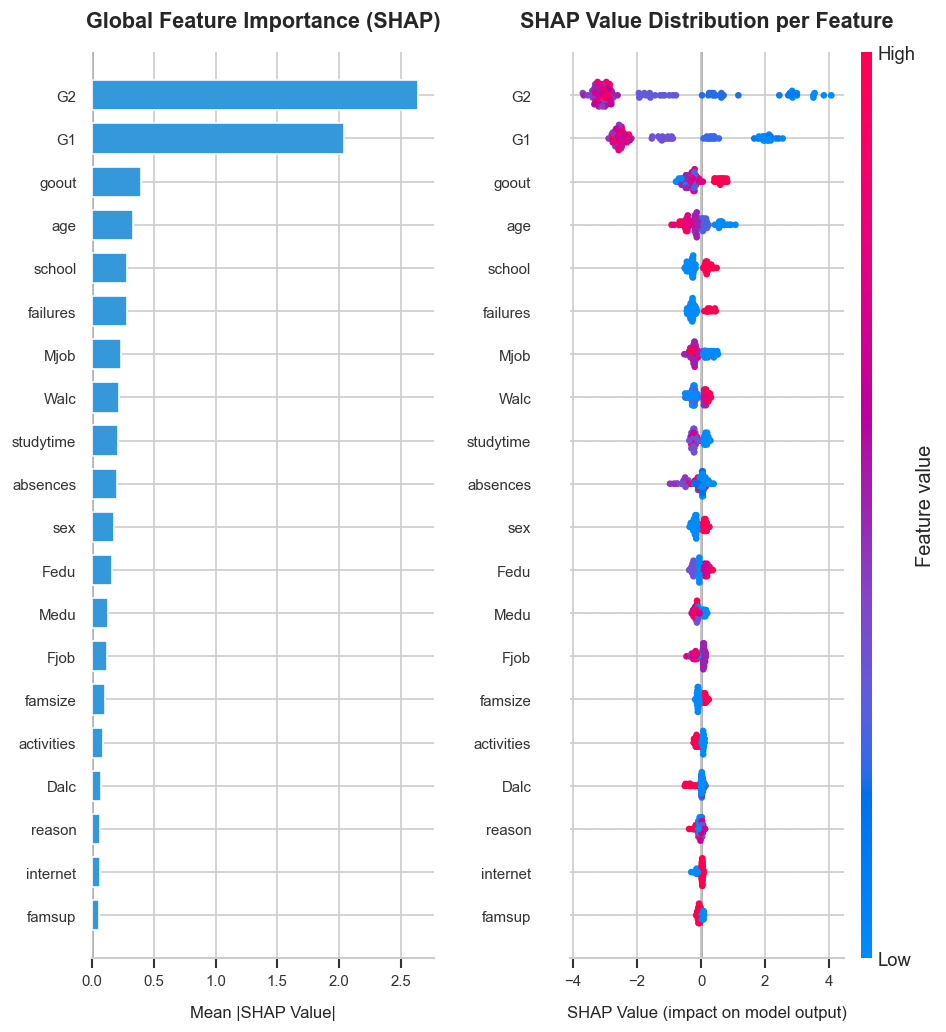

In [10]:
fig = plt.figure(figsize=(20, 8))

# Left: bar plot
ax1 = fig.add_subplot(1, 2, 1)
plt.sca(ax1)
shap.summary_plot(
    shap_values, X_test,
    plot_type="bar",
    show=False,
    color="#3498db"
)
ax1.set_title("Global Feature Importance (SHAP)",
              fontsize=13, fontweight="bold", pad=15)
ax1.set_xlabel("Mean |SHAP Value|", fontsize=10, labelpad=10)
ax1.tick_params(axis="both", labelsize=9)

# Right: beeswarm
ax2 = fig.add_subplot(1, 2, 2)
plt.sca(ax2)
shap.summary_plot(
    shap_values, X_test,
    plot_type="dot",
    show=False
)
ax2.set_title("SHAP Value Distribution per Feature",
              fontsize=13, fontweight="bold", pad=15)
ax2.set_xlabel("SHAP Value (impact on model output)",
               fontsize=10, labelpad=10)
ax2.tick_params(axis="both", labelsize=9)

fig.subplots_adjust(bottom=0.15, wspace=0.4)

plt.show()

###  Per-student waterfall

Student index      : 7
True label         : At-Risk
Predicted prob     : 0.951
G1 (original)      : 7.0
G2 (original)      : 8.0


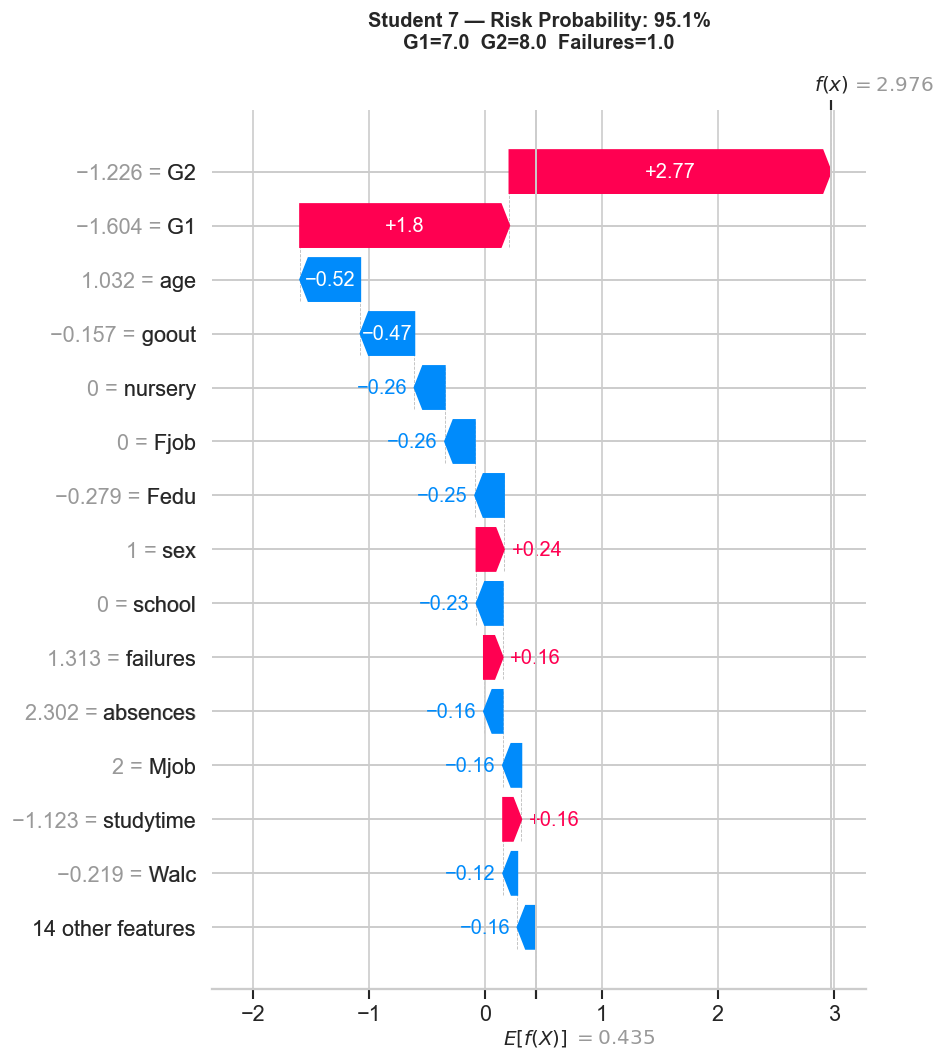

In [13]:
at_risk_indices = np.where(y_test.values == 1)[0]
student_idx     = at_risk_indices[0]

print(f"Student index      : {student_idx}")
print(f"True label         : At-Risk")
print(f"Predicted prob     : {xgb_model.predict_proba(X_test)[student_idx][1]:.3f}")
print(f"G1 (original)      : {get_original_value('G1', X_test.iloc[student_idx]['G1'])}")
print(f"G2 (original)      : {get_original_value('G2', X_test.iloc[student_idx]['G2'])}")

# Build SHAP Explanation object
shap_explanation = shap.Explanation(
    values        = shap_values[student_idx],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[student_idx].values,
    feature_names = list(X_test.columns)
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_explanation, show=False, max_display=15)
plt.title(
    f"Student {student_idx} — Risk Probability: "
    f"{xgb_model.predict_proba(X_test)[student_idx][1]*100:.1f}%\n"
    f"G1={get_original_value('G1', X_test.iloc[student_idx]['G1'])}  "
    f"G2={get_original_value('G2', X_test.iloc[student_idx]['G2'])}  "
    f"Failures={get_original_value('failures', X_test.iloc[student_idx]['failures'])}",
    fontsize=12, fontweight="bold", pad=15
)
plt.tight_layout()
plt.show()

#### JSON formatter for the API

In [11]:
# ── Inverse transform scaled values back to original ─────────────
# Build a lookup: col_name → index in SCALE_COLS
scale_idx = {col: i for i, col in enumerate(SCALE_COLS)}

def get_original_value(col, scaled_val):
    """
    Returns the original unscaled value for display to faculty.
    For scaled columns: inverse_transform using scaler mean/std.
    For binary/ordinal columns: value is already human-readable.
    """
    if col in scale_idx:
        idx  = scale_idx[col]
        mean = scaler.mean_[idx]
        std  = scaler.scale_[idx]
        return round(float(scaled_val * std + mean), 2)
    return round(float(scaled_val), 2)

# ── Per-student SHAP formatter ────────────────────────────────────
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer,)):  return int(obj)
        if isinstance(obj, (np.floating,)): return float(obj)
        if isinstance(obj, np.ndarray):     return obj.tolist()
        return super().default(obj)

def format_shap_for_api(student_idx, shap_vals, explainer,
                         X_scaled_data, X_original, y_true, model):
    """
    Returns clean JSON with:
    - original (unscaled) feature values for faculty readability
    - SHAP values for waterfall rendering
    - top risk factors and protectors
    """
    pred_prob  = float(model.predict_proba(X_scaled_data)[student_idx][1])
    pred_label = int(model.predict(X_scaled_data)[student_idx])
    true_label = int(y_true.iloc[student_idx])

    contributions = []
    for feat, shap_val, scaled_val in zip(
        X_scaled_data.columns,
        shap_vals[student_idx],
        X_scaled_data.iloc[student_idx].values
    ):
        original_val = get_original_value(feat, scaled_val)
        contributions.append({
            "feature"       : str(feat),
            "shap_value"    : round(float(shap_val), 4),
            "feature_value" : original_val,   # ← original, readable
            "direction"     : "risk" if shap_val > 0 else "protective"
        })

    contributions.sort(key=lambda x: abs(x["shap_value"]), reverse=True)

    return {
        "student_index"    : student_idx,
        "true_label"       : true_label,
        "predicted_label"  : pred_label,
        "risk_probability" : round(pred_prob, 4),
        "risk_percent"     : round(pred_prob * 100, 1),
        "baseline_value"   : round(float(explainer.expected_value), 4),
        "top_risk_factors" : [c for c in contributions
                               if c["direction"] == "risk"][:5],
        "top_protectors"   : [c for c in contributions
                               if c["direction"] == "protective"][:5],
        "all_contributions": contributions
    }

In [12]:
# ── Test on first at-risk student ────────────────────────────────
at_risk_indices = np.where(y_test.values == 1)[0]
student_idx     = at_risk_indices[0]

# X_original = unscaled version for value lookup
X_original = X.loc[X_test.index]

result = format_shap_for_api(
    student_idx    = student_idx,
    shap_vals      = shap_values,
    explainer      = explainer,
    X_scaled_data  = X_test,
    X_original     = X_original,
    y_true         = y_test,
    model          = xgb_model
)

print(json.dumps({
    "student_index"   : result["student_index"],
    "risk_probability": result["risk_probability"],
    "risk_percent"    : result["risk_percent"],
    "predicted_label" : result["predicted_label"],
    "baseline_value"  : result["baseline_value"],
    "top_risk_factors": result["top_risk_factors"],
    "top_protectors"  : result["top_protectors"]
}, indent=2, cls=NumpyEncoder))

{
  "student_index": 7,
  "risk_probability": 0.9515,
  "risk_percent": 95.1,
  "predicted_label": 1,
  "baseline_value": 0.4352,
  "top_risk_factors": [
    {
      "feature": "G2",
      "shap_value": 2.7705,
      "feature_value": 8.0,
      "direction": "risk"
    },
    {
      "feature": "G1",
      "shap_value": 1.8032,
      "feature_value": 7.0,
      "direction": "risk"
    },
    {
      "feature": "sex",
      "shap_value": 0.2383,
      "feature_value": 1.0,
      "direction": "risk"
    },
    {
      "feature": "failures",
      "shap_value": 0.1643,
      "feature_value": 1.0,
      "direction": "risk"
    },
    {
      "feature": "studytime",
      "shap_value": 0.1586,
      "feature_value": 1.0,
      "direction": "risk"
    }
  ],
  "top_protectors": [
    {
      "feature": "age",
      "shap_value": -0.5197,
      "feature_value": 18.0,
      "direction": "protective"
    },
    {
      "feature": "goout",
      "shap_value": -0.4659,
      "feature_value": 3.0,


#### Saving

In [14]:
# Save explainer
joblib.dump(explainer,    os.path.join(MODELS_DIR, "shap_explainer.pkl"))

# Save shap values for test set (cohort-level API endpoint later)
joblib.dump(shap_values,  os.path.join(MODELS_DIR, "shap_values_test.pkl"))

# Write shap_formatter.py to services directory
SERVICES_DIR = os.path.join(BASE_DIR, "..", "app", "services")
os.makedirs(SERVICES_DIR, exist_ok=True)

In [15]:
formatter_code = '''\
import numpy as np
import json


class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer,)):  return int(obj)
        if isinstance(obj, (np.floating,)): return float(obj)
        if isinstance(obj, np.ndarray):     return obj.tolist()
        return super().default(obj)


def get_original_value(col, scaled_val, scaler, scale_cols):
    scale_idx = {c: i for i, c in enumerate(scale_cols)}
    if col in scale_idx:
        idx  = scale_idx[col]
        mean = scaler.mean_[idx]
        std  = scaler.scale_[idx]
        return round(float(scaled_val * std + mean), 2)
    return round(float(scaled_val), 2)


def format_shap_for_api(student_idx, shap_vals, explainer,
                         X_scaled_data, y_true, model,
                         scaler, scale_cols):
    pred_prob  = float(model.predict_proba(X_scaled_data)[student_idx][1])
    pred_label = int(model.predict(X_scaled_data)[student_idx])
    true_label = int(y_true.iloc[student_idx]) if y_true is not None else None

    contributions = []
    for feat, shap_val, scaled_val in zip(
        X_scaled_data.columns,
        shap_vals[student_idx],
        X_scaled_data.iloc[student_idx].values
    ):
        original_val = get_original_value(feat, scaled_val,
                                          scaler, scale_cols)
        contributions.append({
            "feature"      : str(feat),
            "shap_value"   : round(float(shap_val), 4),
            "feature_value": original_val,
            "direction"    : "risk" if shap_val > 0 else "protective"
        })

    contributions.sort(key=lambda x: abs(x["shap_value"]), reverse=True)

    return {
        "student_index"   : student_idx,
        "true_label"      : true_label,
        "predicted_label" : pred_label,
        "risk_probability": round(pred_prob, 4),
        "risk_percent"    : round(pred_prob * 100, 1),
        "baseline_value"  : round(float(explainer.expected_value), 4),
        "top_risk_factors": [c for c in contributions
                              if c["direction"] == "risk"][:5],
        "top_protectors"  : [c for c in contributions
                              if c["direction"] == "protective"][:5],
        "all_contributions": contributions
    }
'''

formatter_path = os.path.join(SERVICES_DIR, "shap_formatter.py")
with open(formatter_path, "w") as f:
    f.write(formatter_code)

In [16]:
# ── Final inventory ───────────────────────────────────────────────
print("=" * 50)
print("PHASE 1 COMPLETE — Saved Artifacts")
print("=" * 50)
print(f"\nModel artifacts ({MODELS_DIR}):")
for fname in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(os.path.join(MODELS_DIR, fname))
    print(f"  {fname:<30} {size/1024:.1f} KB")

print(f"\nService files ({SERVICES_DIR}):")
for fname in sorted(os.listdir(SERVICES_DIR)):
    size = os.path.getsize(os.path.join(SERVICES_DIR, fname))
    print(f"  {fname:<30} {size/1024:.1f} KB")

PHASE 1 COMPLETE — Saved Artifacts

Model artifacts (C:\Users\RAJA\Desktop\DA\Projects\FailSafe\backend\ml\models):
  encoders.pkl                   4.2 KB
  feature_cols.pkl               0.3 KB
  metadata.pkl                   0.8 KB
  rf_model.pkl                   1111.3 KB
  scaler.pkl                     1.1 KB
  shap_explainer.pkl             728.2 KB
  shap_values_test.pkl           14.4 KB
  xgb_model.pkl                  256.0 KB

Service files (C:\Users\RAJA\Desktop\DA\Projects\FailSafe\backend\ml\..\app\services):
  shap_formatter.py              2.3 KB
